In [17]:
# Fan In Fan Out
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class BlogState(TypedDict):
    topic: str
    intro: str
    examples: str
    code: str
    final_blog: str
    valid: bool


In [18]:
def planner(state: BlogState):
    return state

def write_intro(state: BlogState):
    return {
        "intro": f"Introduction to {state['topic']}"
    }

def write_examples(state: BlogState):
    return {
        "examples": f"Examples of {state['topic']}"
    }

def write_codes(state: BlogState):
    return {
        "code": f"Codes of {state['topic']}"
    }

def merger(state: BlogState):
    final_blog = (
        state['intro'] + '\n' + state['examples'] + '\n' + state['code']
    )
    return {'final_blog': final_blog}

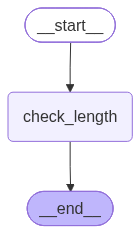

In [19]:
# Example - Sub graph for input validation
class TopicValidation(TypedDict):
    topic: str
    valid: bool

# Node
def check_length(state: TopicValidation) -> dict:
    topic = state['topic']
    if len(topic) < 5:
        state['valid'] = False
    else:
        state['valid'] = True
    return state

sub_graph_builder = StateGraph(TopicValidation)

sub_graph_builder.add_node("check_length", check_length)
sub_graph_builder.add_edge(START, "check_length")
sub_graph_builder.add_edge("check_length", END)

sub_graph = sub_graph_builder.compile()
sub_graph

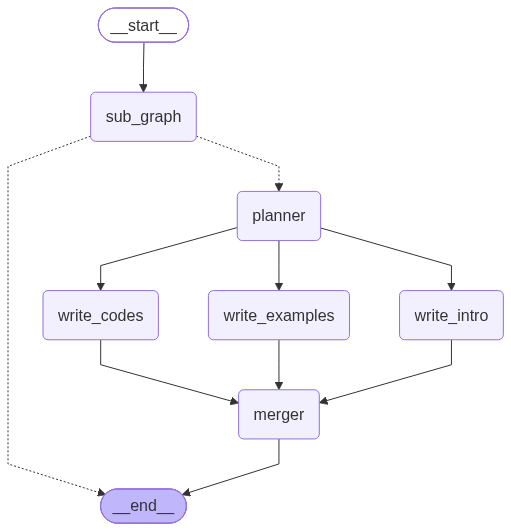

In [20]:
from typing import Annotated, TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

graph = StateGraph(BlogState)

graph.add_node("planner", planner)
graph.add_node("write_intro", write_intro)
graph.add_node("write_examples", write_examples)
graph.add_node("write_codes", write_codes)
graph.add_node("merger", merger)
# Every sub-graph is mapped as a Node
graph.add_node("sub_graph", sub_graph)

graph.add_edge(START, "sub_graph")

graph.add_conditional_edges(
    "sub_graph",
    lambda _state: "planner" if _state['valid'] else END,
    {"planner": "planner", END: END}
)

# Fan-Out
graph.add_edge("planner", "write_intro")
graph.add_edge("planner", "write_examples")
graph.add_edge("planner", "write_codes")

graph.add_edge("write_intro", "merger")
graph.add_edge("write_examples", "merger")
graph.add_edge("write_codes", "merger")

graph.add_edge("merger", END)

graph_app = graph.compile()
graph_app


In [26]:
result = graph_app.invoke({
    "topic": "AI"
})

print(result)

{'topic': 'AI', 'valid': False}
